<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/Taller/Taller_IQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demostración: $A_c(t)$ y $A_s(t)$ son procesos Gaussianos

## 1. Planteamiento

Sea $\xi(t)$ un proceso aleatorio Gaussiano. La señal narrowband puede representarse como:

$$
\xi(t) = A_c(t)\cos(\omega_0 t) - A_s(t)\sin(\omega_0 t)
$$

donde:

$$
A_c(t) = \text{LPF}\{\xi(t)\cos(\omega_0 t)\}, \quad
A_s(t) = \text{LPF}\{\xi(t)\sin(\omega_0 t)\}
$$

y LPF denota un filtro pasa-bajas.

---

## 2. Propiedad fundamental

Si $\xi(t)$ es un proceso Gaussiano, entonces:

> Cualquier transformación lineal de $\xi(t)$ también es un proceso Gaussiano.

---

## 3. Demostración para $A_c(t)$

### Paso 1: Multiplicación por una función determinística

Consideremos:

$$
y_1(t) = \xi(t)\cos(\omega_0 t)
$$

Como $\cos(\omega_0 t)$ es determinística, $y_1(t)$ es Gaussiano.

---

### Paso 2: Aplicación de un filtro lineal

El filtro pasa-bajas puede escribirse como:

$$
A_c(t) = \int_{-\infty}^{\infty} h(\tau)\, y_1(t-\tau)\, d\tau
$$

$$
A_c(t) = \int_{-\infty}^{\infty} h(\tau)\,\xi(t-\tau)\cos(\omega_0 (t-\tau))\, d\tau
$$

Esto es una combinación lineal de valores de $\xi(t)$.

Por lo tanto:

$$
A_c(t) \text{ es Gaussiano}
$$

---

## 4. Demostración para $A_s(t)$

De forma análoga:

$$
A_s(t) = \text{LPF}\{\xi(t)\sin(\omega_0 t)\}
$$

Siguiendo los mismos pasos:

- Multiplicación por función determinística
- Filtrado lineal

Se concluye que:

$$
A_s(t) \text{ es Gaussiano}
$$

---

## 5. Conclusión

Dado que ambas funciones se obtienen mediante transformaciones lineales de un proceso Gaussiano:

$$
A_c(t) \sim \mathcal{N}(\mu_c, \sigma_c^2)
$$

$$
A_s(t) \sim \mathcal{N}(\mu_s, \sigma_s^2)
$$

Por lo tanto:

> $A_c(t)$ y $A_s(t)$ son procesos Gaussianos.

---

## 6. Caso de media cero

Si:

$$
\mathbb{E}[\xi(t)] = 0
$$

entonces:

$$
\mathbb{E}[A_c(t)] = 0, \quad \mathbb{E}[A_s(t)] = 0
$$

---

## 7. Interpretación

$A_c(t)$ y $A_s(t)$ representan las componentes en fase y en cuadratura (I/Q) de la señal, y corresponden a proyecciones lineales de un proceso Gaussiano, lo cual preserva la naturaleza Gaussiana.

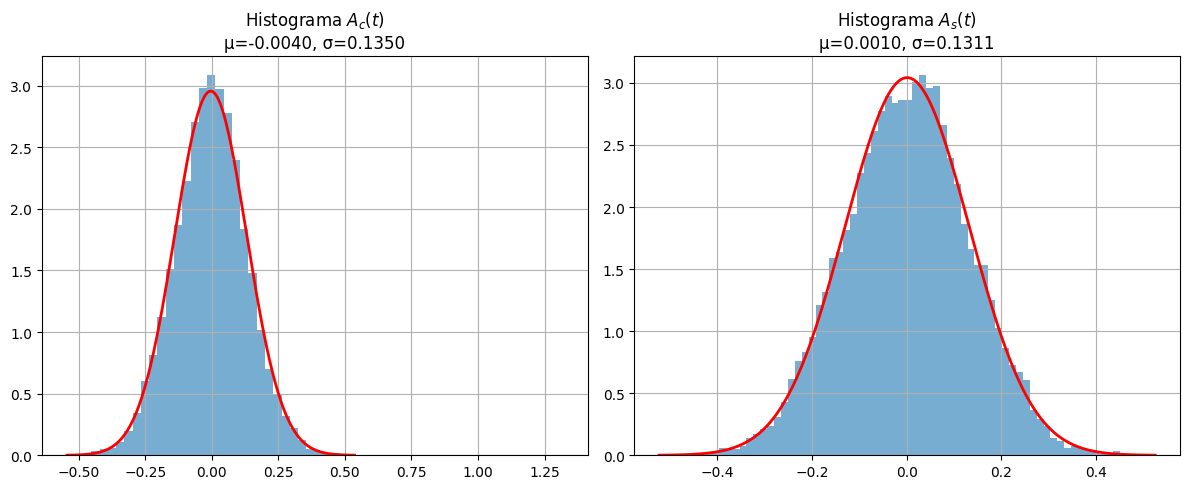

---- MEDIA Y VARIANZA ----
Media Ac: -0.003981753001388276
Media As: 0.000998092925799352
Varianza Ac: 0.018215106720638967
Varianza As: 0.017190809498525143

---- COVARIANZA ----
Cov(Ac, As): -0.00022205308709021587


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import norm

# -----------------------------
# 1. Parámetros
# -----------------------------
fs = 1000
t = np.arange(0, 30, 1/fs)   # más tiempo → mejor aproximación
f0 = 50
w0 = 2*np.pi*f0

# -----------------------------
# 2. Filtro pasa-bajas
# -----------------------------
def lowpass(signal, cutoff=20, fs=1000, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

# -----------------------------
# 3. Proceso Gaussiano ξ(t)
# -----------------------------
xi = np.random.normal(0, 1, len(t))

# -----------------------------
# 4. Obtener Ac y As
# -----------------------------
xi_cos = xi * np.cos(w0 * t)
xi_sin = xi * np.sin(w0 * t)

Ac = lowpass(xi_cos, cutoff=20, fs=fs)
As = lowpass(xi_sin, cutoff=20, fs=fs)

# -----------------------------
# 5. HISTOGRAMAS (Gaussianidad)
# -----------------------------
def plot_hist(data, title):
    mu, std = np.mean(data), np.std(data)
    plt.hist(data, bins=60, density=True, alpha=0.6)
    x = np.linspace(mu - 4*std, mu + 4*std, 200)
    plt.plot(x, norm.pdf(x, mu, std), 'r', linewidth=2)
    plt.title(f"{title}\nμ={mu:.4f}, σ={std:.4f}")
    plt.grid()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_hist(Ac, "Histograma $A_c(t)$")

plt.subplot(1,2,2)
plot_hist(As, "Histograma $A_s(t)$")

plt.tight_layout()
plt.show()

# -----------------------------
# 6. MEDIA Y VARIANZA
# -----------------------------
print("---- MEDIA Y VARIANZA ----")
print("Media Ac:", np.mean(Ac))
print("Media As:", np.mean(As))
print("Varianza Ac:", np.var(Ac))
print("Varianza As:", np.var(As))

# -----------------------------
# 7. COVARIANZA
# -----------------------------
cov_matrix = np.cov(Ac, As)
cov = cov_matrix[0,1]

print("\n---- COVARIANZA ----")
print("Cov(Ac, As):", cov)



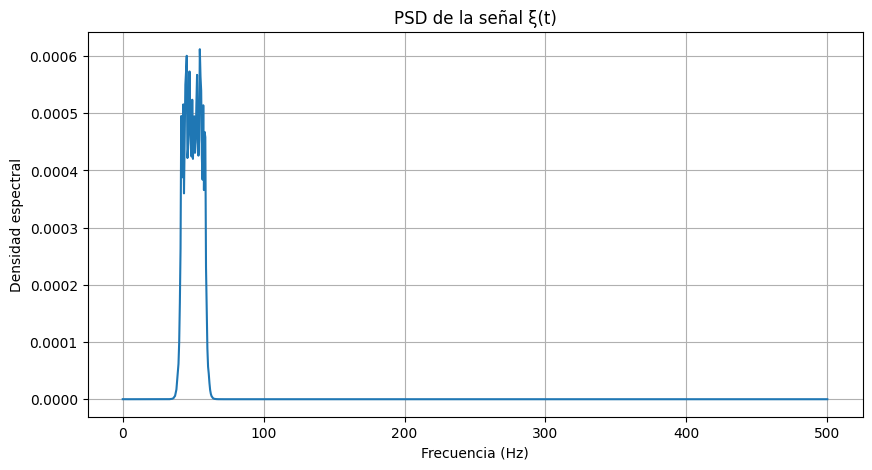

Error de simetría alrededor de f0: 6.901367442704454e-05


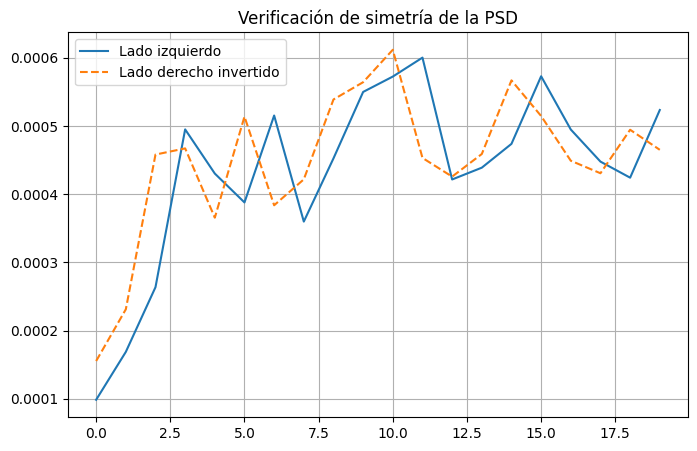

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# 1. Parámetros
# -----------------------------
fs = 1000
t = np.arange(0, 30, 1/fs)
f0 = 50   # frecuencia central

# -----------------------------
# 2. Generar señal narrowband
# -----------------------------
# Ruido base (lowpass)
noise = np.random.normal(0, 1, len(t))

# Filtro simple (suavizado tipo LPF)
from scipy.signal import butter, filtfilt
def lowpass(signal, cutoff=10, fs=1000):
    b, a = butter(4, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)

baseband = lowpass(noise, cutoff=10, fs=fs)

# Modulación → narrowband alrededor de f0
xi = baseband * np.cos(2*np.pi*f0*t)

# -----------------------------
# 3. PSD con Welch
# -----------------------------
f, Pxx = welch(xi, fs=fs, nperseg=2048)

# -----------------------------
# 4. Gráfica PSD
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(f, Pxx)
plt.title("PSD de la señal ξ(t)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral")
plt.grid()
plt.show()

# -----------------------------
# 5. Verificar simetría alrededor de f0
# -----------------------------
# Tomar ventana alrededor de f0
delta = 20  # ancho de análisis

# índices cercanos a f0
idx_center = np.argmin(np.abs(f - f0))

# comparar lados izquierdo y derecho
left = Pxx[idx_center - delta:idx_center]
right = Pxx[idx_center+1:idx_center + delta + 1]

# invertir uno para comparar simetría
right_flipped = right[::-1]

# error de simetría
error = np.mean(np.abs(left - right_flipped))

print("Error de simetría alrededor de f0:", error)

# -----------------------------
# 6. Gráfica comparativa
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(left, label="Lado izquierdo")
plt.plot(right_flipped, '--', label="Lado derecho invertido")
plt.title("Verificación de simetría de la PSD")
plt.legend()
plt.grid()
plt.show()

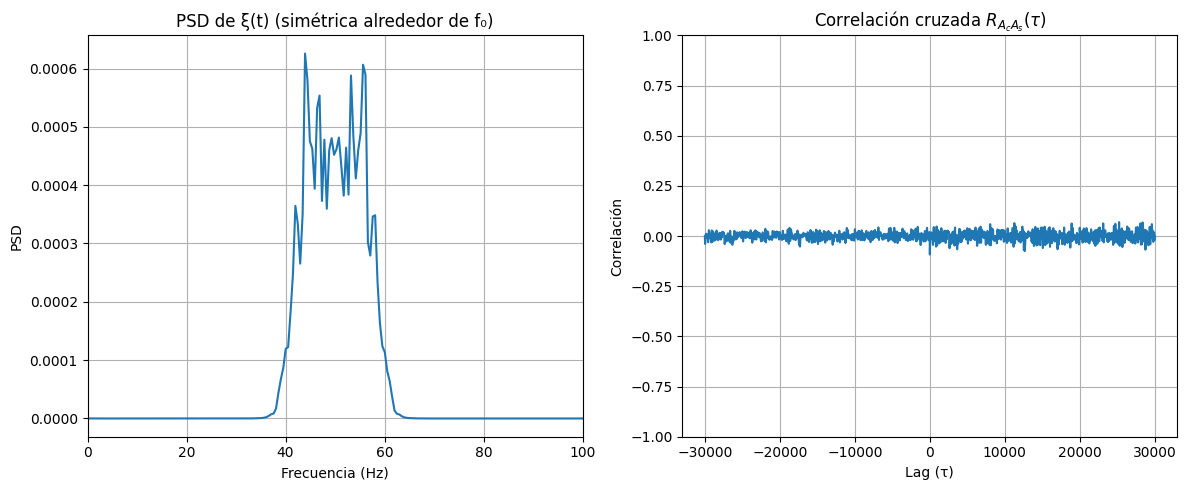

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

# -----------------------------
# 1. Parámetros
# -----------------------------
fs = 1000
t = np.arange(0, 30, 1/fs)
f0 = 50
w0 = 2*np.pi*f0

# -----------------------------
# 2. Filtro pasa-bajas
# -----------------------------
def lowpass(signal, cutoff=10, fs=1000):
    b, a = butter(4, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)

# -----------------------------
# 3. Señal narrowband
# -----------------------------
noise = np.random.normal(0, 1, len(t))
baseband = lowpass(noise, cutoff=10, fs=fs)

xi = baseband * np.cos(2*np.pi*f0*t)

# -----------------------------
# 4. Obtener Ac y As
# -----------------------------
xi_cos = xi * np.cos(w0 * t)
xi_sin = xi * np.sin(w0 * t)

Ac = lowpass(xi_cos, cutoff=10, fs=fs)
As = lowpass(xi_sin, cutoff=10, fs=fs)

# -----------------------------
# 5. PSD
# -----------------------------
f, Pxx = welch(xi, fs=fs, nperseg=2048)

# -----------------------------
# 6. Correlación cruzada
# -----------------------------
Ac_c = Ac - np.mean(Ac)
As_c = As - np.mean(As)

corr = np.correlate(Ac_c, As_c, mode='full')
lags = np.arange(-len(Ac)+1, len(Ac))

# normalizar
corr = corr / (np.std(Ac)*np.std(As)*len(Ac))

# -----------------------------
# 7. Gráficas
# -----------------------------
plt.figure(figsize=(12,5))

# PSD
plt.subplot(1,2,1)
plt.plot(f, Pxx)
plt.xlim(0,100)
plt.title("PSD de ξ(t) (simétrica alrededor de f₀)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD")
plt.grid()

# Correlación cruzada
plt.subplot(1,2,2)
plt.plot(lags, corr)
plt.title("Correlación cruzada $R_{A_cA_s}(\\tau)$")
plt.xlabel("Lag (τ)")
plt.ylim(-1,1)
#plt.xlim(500,500)
plt.ylabel("Correlación")
plt.grid()

plt.tight_layout()
plt.show()